<a href="https://colab.research.google.com/github/XanderPatterson/4487-IS-Class-Labs/blob/main/lab_05_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> ### Note on Labs and Assignments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 5: EDA

## Outline

- Univariate analysis (distributions, histograms, counts)
- Bivariate analysis (correlations, scatterplots, group comparisons)
- Reflections and insights

This lab uses the same dataset from **Lab 4**. You will see some overlap in the initial tasks as the data is cleaned.  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## SF Rentals - Business Context

This dataset represents actual rental listings in the San Francisco housing market, which is known for its high prices, competitive demand, and neighborhood-level variation. In a business context, this type of data could be used by real estate companies, rental platforms, investors, or property managers to better understand pricing trends and market dynamics. The variables provide multiple angles for analysis: pricing (price) can be compared with property features like size (sqft), bedrooms and bathrooms, and whether the listing is a full apartment or just a room; location data (nhood, lat, lon) allows for geographic analysis of rent differences across neighborhoods; and time variables (date, year) help track how the market changes over time. Text fields like title and descr can even be analyzed to understand how listings are marketed. By exploring this dataset, analysts can answer questions such as what factors drive higher rent, which neighborhoods are most expensive, or how prices have changed over time. This kind of analysis is valuable for setting competitive prices, identifying investment opportunities, and helping renters or companies make informed housing decisions.

Note that many of the columns (variables) will be empty.  This is an unfortunate reality in the real world!

Some rentals are apartments, others are for homes, and there may be some other random properties for rent.  Each row represents one rental listing.

**Source:** Pennington, Kate (2018). Bay Area Craigslist Rental Housing Posts, 2000-2018. Retrieved from [Github](https://github.com/katepennington/historic_bay_area_craigslist_housing_posts/blob/master/clean_2000_2018.csv.zip).

## Data Dictionary

| Variable       | Type       | Description |
|----------------|------------|-------------|
| `post_id`      | Categorical| Unique listing ID |
| `date`         | Numeric    | Listing date (numeric format) |
| `year`         | Integer    | Year of listing |
| `nhood`        | Categorical| Neighborhood |
| `city`         | Categorical| City |
| `county`       | Categorical| County |
| `price`        | Numeric    | Listing price (USD) |
| `beds`         | Numeric    | Number of bedrooms |
| `baths`        | Numeric    | Number of bathrooms |
| `sqft`         | Numeric    | Square footage |
| `room_in_apt`  | Binary     | Indicates whether the rental listing is for an entire apartment (0) or a single room within an apartment (1)|
| `address`      | Categorical| Street address |
| `lat`          | Numeric    | Latitude |
| `lon`          | Numeric    | Longitude |
| `title`        | Text       | Listing title |
| `descr`        | Text       | Listing description |
| `details`      | Text       | Additional details |


## 1. Importing the Data

### Instructions:
- Import the `pandas` library for dataframes.  Then `Matplotlib` and `Seaborn` for data visualization.
- Import data from the rent.csv into a dataframe from the tidytuesday link.
- Use `.info()` and `.head()` to inspect the structure and preview the data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/rent.csv'
df = pd.read_csv(url)

/tmp/ipykernel_455/4027342650.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


In [3]:
# Get summary info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200810 entries, 0 to 200809
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   post_id      200810 non-null  object 
 1   date         200797 non-null  object 
 2   year         200796 non-null  float64
 3   nhood        200796 non-null  object 
 4   city         200796 non-null  object 
 5   county       199402 non-null  object 
 6   price        200796 non-null  float64
 7   beds         194188 non-null  float64
 8   baths        42675 non-null   float64
 9   sqft         64679 non-null   float64
 10  room_in_apt  200796 non-null  float64
 11  address      3908 non-null    object 
 12  lat          7651 non-null    float64
 13  lon          4312 non-null    float64
 14  title        198279 non-null  object 
 15  descr        3254 non-null    object 
 16  details      8015 non-null    object 
dtypes: float64(8), object(9)
memory usage: 26.0+ MB


In [5]:
# Preview the first rows
df.head(10)

,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
0,pre2013_134138,20050111,2005.0,alameda,alameda,alameda,1250.0,2.0,2.0,NaN,0.0,NaN,NaN,NaN,$1250 / 2br - 2BR/2BA 1145 ALAMEDA DE LAS PU...,NaN,NaN
1,pre2013_135669,20050126,2005.0,alameda,alameda,alameda,1295.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1295 / 2br - Walk the Beach! 1 FREE MONTH + $...,NaN,NaN
2,pre2013_127127,20041017,2004.0,alameda,alameda,alameda,1100.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1100 / 2br - cottage,NaN,NaN
3,pre2013_68671,20120601,2012.0,alameda,alameda,alameda,1425.0,1.0,NaN,735.0,0.0,NaN,NaN,NaN,$1425 / 1br - 735ft² - BEST LOCATION SOUTHSHOR...,NaN,NaN
4,pre2013_127580,20041021,2004.0,alameda,alameda,alameda,890.0,1.0,NaN,NaN,0.0,NaN,NaN,NaN,"$890 / 1br - Classy ""Painted Lady"" VICTORIAN -...",NaN,NaN
5,pre2013_152345,20060411,2006.0,alameda,alameda,alameda,825.0,1.0,NaN,NaN,0.0,NaN,NaN,NaN,$825 / 1br - Bayview Apartments,NaN,NaN
6,pre2013_27543,20071025,2007.0,alameda,alameda,alameda,1500.0,1.0,1.0,NaN,0.0,NaN,NaN,NaN,$1500 / 1br - 1 Bath-3 Room Apartment - OPEN S...,NaN,NaN
7,6379096957,20171108,2017.0,alameda,alameda,alameda,2925.0,3.0,NaN,NaN,0.0,NaN,NaN,NaN,CUT DOWN ON THOSE MOVE-IN COSTS WITH $500 OFF!!!,NaN,NaN
8,pre2013_6254,20090205,2009.0,alameda,alameda,alameda,450.0,NaN,1.0,NaN,0.0,NaN,NaN,NaN,"$450 Sleeping room, all utilities included, sh...",NaN,NaN
9,pre2013_152262,20060411,2006.0,alameda,alameda,alameda,1395.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,"$1395 / 2br - Huge Units! Lagoon Complex, Free...",NaN,NaN


## 2. Inspecting Data Quality

### Instructions:
- Check for outliers or invalid data in key numeric variables like `price`, `sqft`, `beds`, or `baths`.  The concept of outliers will be covered more in week 6.  This week we will just look for outliers, but we won't take steps to remove them.     

In [6]:
# Basic summary statistics
df[['price', 'beds', 'baths', 'sqft']].describe()

,price,beds,baths,sqft
count,200796.000000,194188.000000,42675.000000,64679.000000
mean,2135.362746,1.889025,1.679086,1201.827688
std,1427.747903,1.079138,0.690509,5000.217864
min,220.000000,0.000000,1.000000,80.000000
25%,1295.000000,1.000000,1.000000,750.000000
50%,1800.000000,2.000000,2.000000,1000.000000
75%,2505.000000,3.000000,2.000000,1360.000000
max,40000.000000,12.000000,8.000000,900000.000000


### Reflection:
- 2.1 Do any numeric variables contain extreme or unusual values?
- 2.2 Should those outlier values be removed?  Or are they valid rental properties?

### ✍️ Your Response: 🔧
2.1 Yes, there are some extreme values in the data. The biggest example is sqft, which has a maximum of 900,000 square feet, compared to a median of 1,000 square feet. Price also has some unusually high values, with a maximum of $40,000 compared to a median of $1,800.

2.2  I would not remove the outliers. Some could be valid rental properties, such as large houses or apartment buildings. However, the 900,000 sqft value seems especially unusual and should be checked for a possible errors before using it in the analysis.

## 3. Univariate Analysis

Explore individual variables to understand their distributions and frequency.

### Tasks:
- Plot histograms for numeric variables (`price`, `sqft`)
- Plot countplots for categorical variables (`beds`, `nhood`)


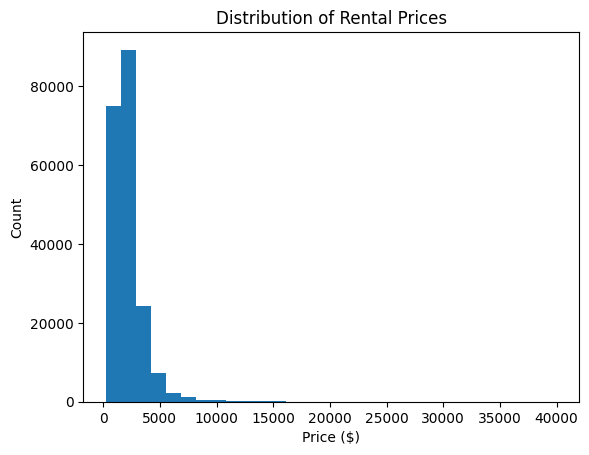

In [7]:
# Histogram: Price
plt.hist(df['price'], bins=30)
plt.title("Distribution of Rental Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

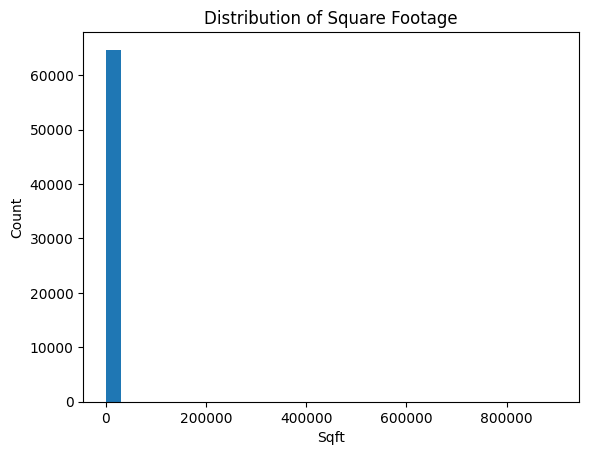

In [8]:
# Histogram: Square Footage
plt.hist(df['sqft'].dropna(), bins=30)
plt.title("Distribution of Square Footage")
plt.xlabel("Sqft")
plt.ylabel("Count")
plt.show()


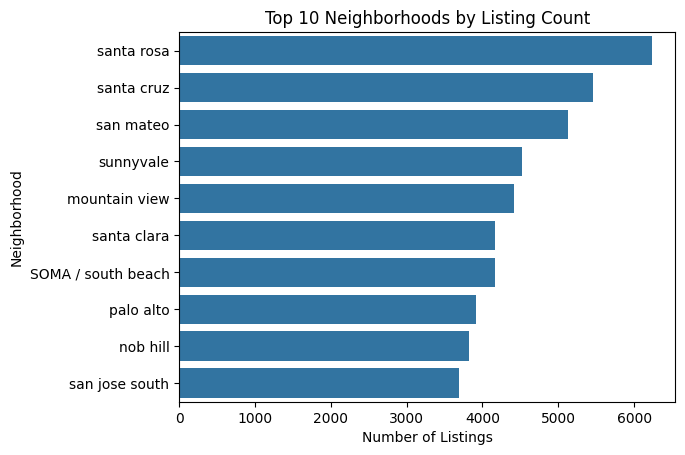

In [9]:
# Bar plot of top 10 neighborhoods by number of listings
top_nhoods = df['nhood'].value_counts().head(10)

sns.barplot(x=top_nhoods.values, y=top_nhoods.index)
plt.title("Top 10 Neighborhoods by Listing Count")
plt.xlabel("Number of Listings")
plt.ylabel("Neighborhood")
plt.show()

### 🔧 Do the following – Part 3

1. Create two new visualizations using different variables than the ones already shown above.

>Suggestions:
- A **histogram** of the `baths` variable
- A **bar chart** showing the **average square footage by number of bathrooms**

> Be sure to label your axes and include a title for each chart.

### Reflection:

After creating each of the visuals, write 1–2 sentences explaining what you notice in each.


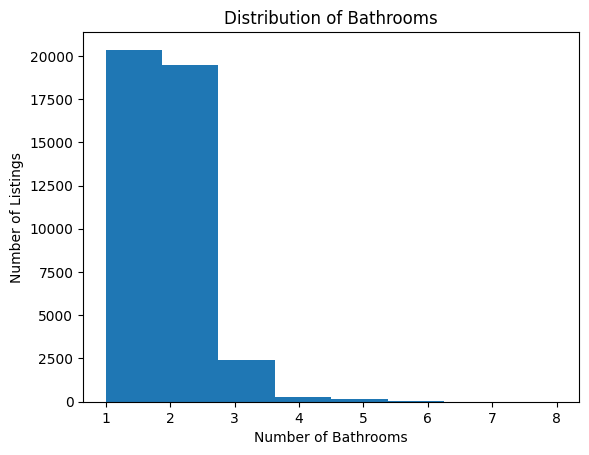

In [10]:
plt.hist(df["baths"].dropna(), bins=8)
plt.xlabel("Number of Bathrooms")
plt.ylabel("Number of Listings")
plt.title("Distribution of Bathrooms")
plt.show()

### ✍️ Visual 1 Response: 🔧
1. There isn't as many listing with more bathrooms which makes sense. There also are more listings with the fewer amount of bathrooms.

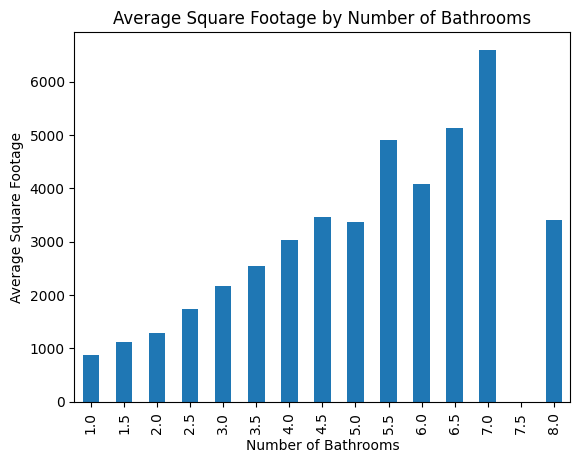

In [11]:
avg_sqft = df.groupby("baths")["sqft"].mean()

avg_sqft.plot(kind="bar")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Average Square Footage")
plt.title("Average Square Footage by Number of Bathrooms")
plt.show()

### ✍️ Visual 2 Response: 🔧
1. Most rental listings have 1 or 2 bathrooms, and the average square footage generally increases as the number of bathrooms increases. There are fewer listings with 4 or more bathrooms, and some of the higher averages may be because of the outliers.

## 4. Bivariate Analysis

Explore relationships between two variables to understand how features like square footage or bedrooms influence price.


In [12]:
# Correlation matrix
corr_matrix = df[['price', 'beds', 'baths', 'sqft']].corr()
corr_matrix


,price,beds,baths,sqft
price,1.000000,0.450096,0.433553,0.074310
beds,0.450096,1.000000,0.651835,0.707235
baths,0.433553,0.651835,1.000000,0.645372
sqft,0.074310,0.707235,0.645372,1.000000


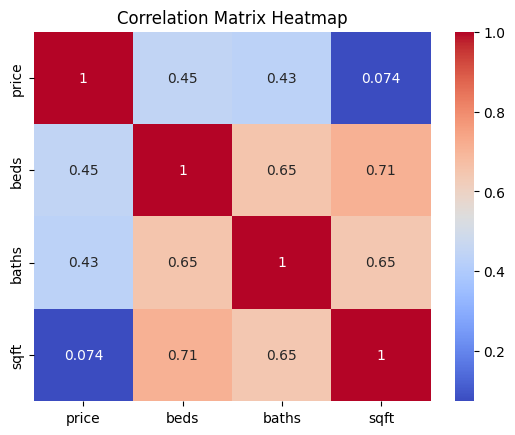

In [13]:
# Heatmap of correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()

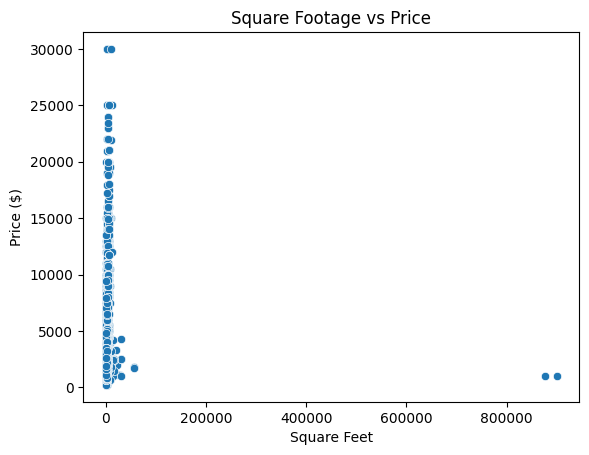

In [14]:
# Scatterplot: Square Footage vs Price
sns.scatterplot(x='sqft', y='price', data=df)
plt.title("Square Footage vs Price")
plt.xlabel("Square Feet")
plt.ylabel("Price ($)")
plt.show()

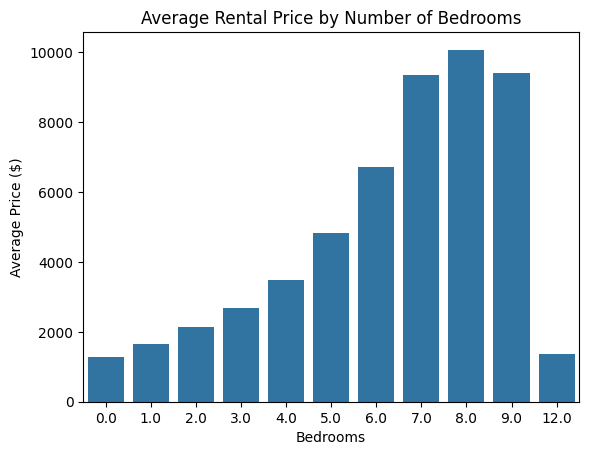

In [15]:
# Average price by number of bedrooms
avg_price_beds = df.groupby('beds')['price'].mean().sort_index()
sns.barplot(x=avg_price_beds.index, y=avg_price_beds.values)
plt.title("Average Rental Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price ($)")
plt.show()

### 🔧 Do the following – Part 4

- 4.1 Create a scatterplot of `baths` vs `price`.  
- 4.2 Group by `year` and plot the average price over time.

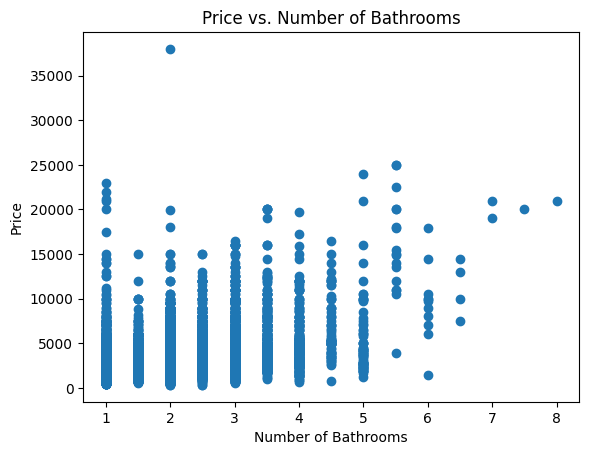

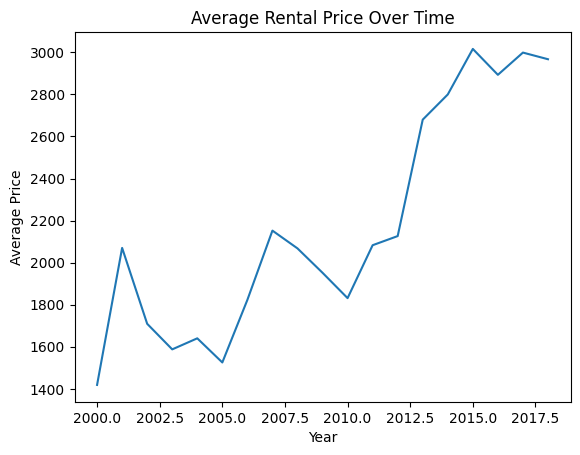

In [17]:
plt.scatter(df["baths"], df["price"])
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price")
plt.title("Price vs. Number of Bathrooms")
plt.show()
avg_price = df.groupby("year")["price"].mean()

avg_price.plot(kind="line")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.title("Average Rental Price Over Time")
plt.show()

### Reflection:
4.1 What trends or outliers do you see?

### ✍️ Your Response: 🔧
4.1 The scatterplot shows that prices vary a lot for each number of bathrooms, but properties with more bathrooms have higher prices. The average rental price also generally increased over time, especially after 2010, although there were some decreases in certain years.

## 🔧  Part 5: Reflection

Answer the following questions in the markdown cell below (no more than a few sentences per question required)

- 5.1 Which variables are most strongly correlated with rental price?
- 5.2 Are there patterns in how size (sqft) or number of bedrooms affects price?
- 5.3 Which neighborhoods or years show the highest prices?
- 5.4 What other visualizations or groupings might improve this analysis?

Use this section to summarize insights from both Labs 4 and 5.

### ✍️ Your Response: 🔧
5.1  The variables most strongly related to rental price appear to be sqft, number of bedrooms, and number of bathrooms. Larger properties and properties with more bedrooms or bathrooms generally have higher prices.

5.2 There is a pattern that larger properties and properties with more bedrooms cost more. However, there are some outliers in sqft and price that can affect this relationship.

5.3 The average rental price was highest around 2015–2018, based on the year analysis. The neighborhoods with the highest prices would need to be compared using the average price for each neighborhood.

5.4 A bar chart of average price by neighborhood and a scatterplot of sqft vs. price would improve this. Grouping properties by bedrooms or bathrooms could also help show how these factors affect rental prices. However knowing how a neighborhood affects price would help a lot.


## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [18]:
!jupyter nbconvert --to html "lab_05_eda.ipynb"

[NbConvertApp] Converting notebook lab_05_eda.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 10 image(s).
[NbConvertApp] Writing 674092 bytes to lab_05_eda.html
